# Analysis for g-BC3

## Electronic density versus energy

In the file `SUMMARY.fcc`

+ The 1st column: lattice parameter (in Å units)
+ The 2nd column: unit number (always 1 in this case)
+ The 3rd column: free energy (in eV units)
+ The 4th column: initial energy (in eV units)
+ The 5th column: energy change (difference between initial and current energy, in eV units)

In [1]:
# Import the necessary packages
import xml.etree.ElementTree as ET

# Analysis vasprun.xml file
tree = ET.parse('1_Lattice_Relaxation_accurate/vasprun.xml')
root = tree.getroot()

# Extract Fermi energy
efermi = float(root.find(".//i[@name='efermi']").text)

# Extract Energies Total DOS Integrated DOS
energies_list, energies_shift, total_dos_list, integrated_dos_list = [], [], [], []

for r_element in root.findall(".//set[@comment='spin 1']/r"):
    values = list(map(float, r_element.text.split()))
    energies = values[0]
    energies_list.append(energies)
    total_dos = values[1]
    total_dos_list.append(total_dos)
    integrated_dos = values[2]
    integrated_dos_list.append(integrated_dos)

# Shift process
shift = efermi; energies_shift = [var - shift for var in energies_list]

print (efermi)
print (energies_list)
print (energies_shift)


-2.85549221
[-20.5301, -20.436, -20.342, -20.2479, -20.1538, -20.0598, -19.9657, -19.8716, -19.7776, -19.6835, -19.5894, -19.4954, -19.4013, -19.3072, -19.2132, -19.1191, -19.025, -18.931, -18.8369, -18.7428, -18.6488, -18.5547, -18.4606, -18.3666, -18.2725, -18.1784, -18.0843, -17.9903, -17.8962, -17.8021, -17.7081, -17.614, -17.5199, -17.4259, -17.3318, -17.2377, -17.1437, -17.0496, -16.9555, -16.8615, -16.7674, -16.6733, -16.5793, -16.4852, -16.3911, -16.2971, -16.203, -16.1089, -16.0148, -15.9208, -15.8267, -15.7326, -15.6386, -15.5445, -15.4504, -15.3564, -15.2623, -15.1682, -15.0742, -14.9801, -14.886, -14.792, -14.6979, -14.6038, -14.5098, -14.4157, -14.3216, -14.2276, -14.1335, -14.0394, -13.9453, -13.8513, -13.7572, -13.6631, -13.5691, -13.475, -13.3809, -13.2869, -13.1928, -13.0987, -13.0047, -12.9106, -12.8165, -12.7225, -12.6284, -12.5343, -12.4403, -12.3462, -12.2521, -12.1581, -12.064, -11.9699, -11.8758, -11.7818, -11.6877, -11.5936, -11.4996, -11.4055, -11.3114, -11.217

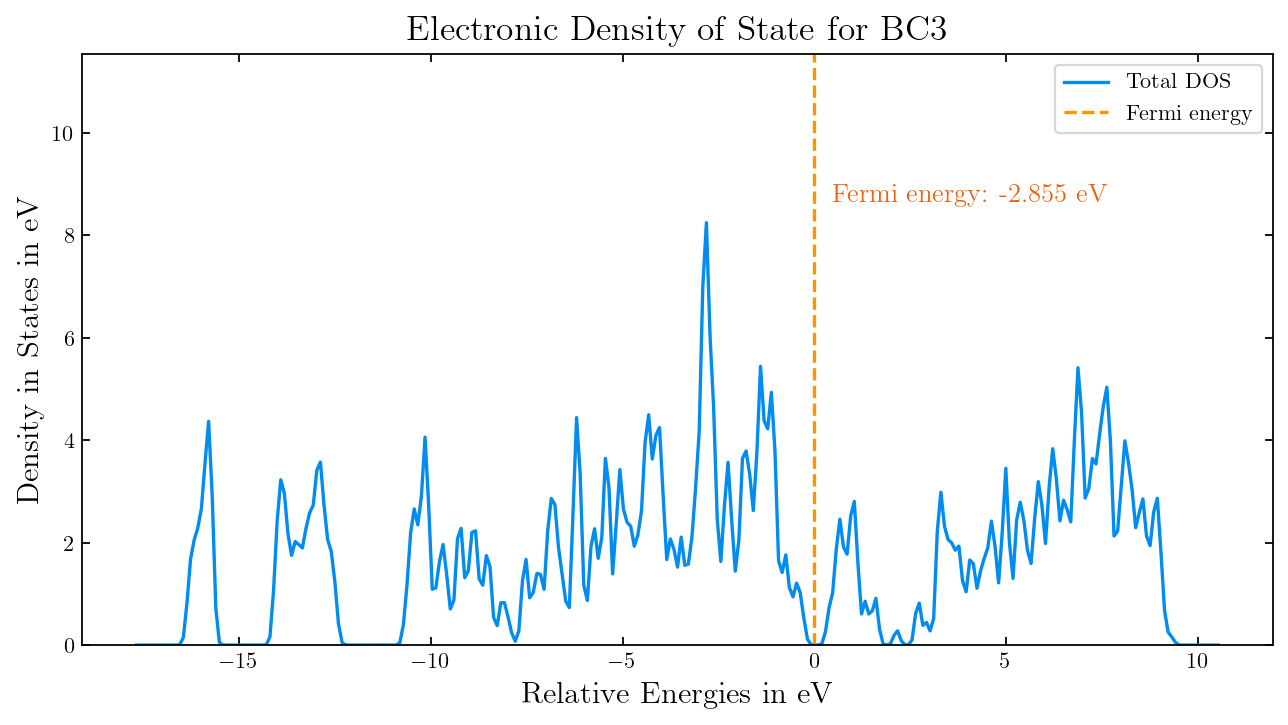

In [2]:
# Import the necessary packages
import matplotlib.pyplot as plt

# Set up the specified style parameters
plt.figure(dpi=160, figsize=(9.6,4.8))
params = {"text.usetex": True, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

plt.title("Electronic Density of State for BC3"); plt.xlabel(r"Relative Energies in eV"); plt.ylabel(r"Density in States in eV")

plt.plot(energies_shift, total_dos_list, c="#008CF0", label="Total DOS"); y_axis_top = max(total_dos_list)
# plt.plot(energies_shift, integrated_dos_list, c="#8C64F0", label="Integrated DOS"); y_axis_top = max(max(total_dos_list), max(integrated_dos_list))

# Plot Fermi energy as a vertical line
plt.axvline(x=efermi-shift, linestyle="--", color="#FA9600", label="Fermi energy")

# Add Fermi energy value to the plot
fermi_energy_text = f"Fermi energy: {efermi:.3f} eV"
plt.text(efermi-shift+0.5, y_axis_top*1.05, fermi_energy_text, fontsize=12, color="#F05F0A", rotation=0)

plt.ylim(0, y_axis_top*1.4)
plt.legend(loc="best")
plt.show()

## Bandstructure

The band structure is demonstrated with Energy (in eV) versus K-point distance (in Å).

/home/lu/.local/lib/python3.11/site-packages/pymatgen/io/vasp/inputs.py:1837: UserWarning: POTCAR with symbol B and functional
PBE has a SHA256 hash defined,
but the computed hash differs.
YOUR POTCAR FILE HAS BEEN CORRUPTED AND SHOULD NOT BE USED!
  warnings.warn(
/home/lu/.local/lib/python3.11/site-packages/pymatgen/io/vasp/inputs.py:1837: UserWarning: POTCAR with symbol C and functional
PBE has a SHA256 hash defined,
but the computed hash differs.
YOUR POTCAR FILE HAS BEEN CORRUPTED AND SHOULD NOT BE USED!
  warnings.warn(


figure numbers: []


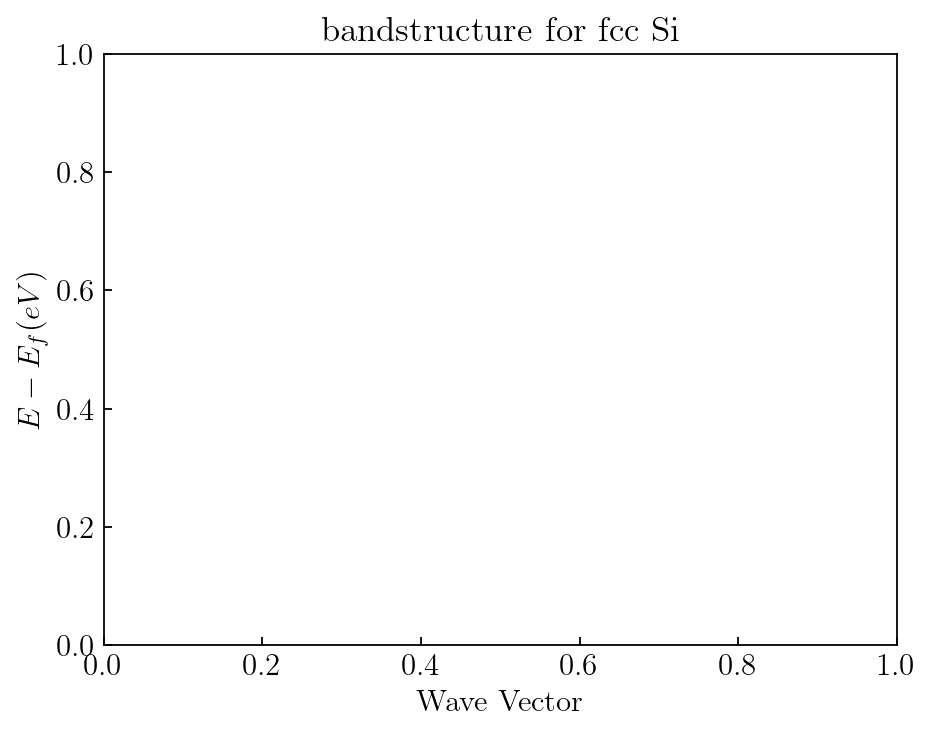

In [3]:
import matplotlib.pyplot as plt
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.io.vasp import Vasprun

# Extract the band structure data from the vasprun.xml file
vasprun = Vasprun("3_Bandstructure/vasprun.xml")
band_structure = vasprun.get_band_structure(line_mode=False) # Save file 

# Use pymatgen's BSPlotter tool to create the band structure plot
plotter = BSPlotter(band_structure)
# plotter.get_plot(ylim=(-20, 40))

# print(electronic_structure.bandstructure.BandStructure.bands)

print("figure numbers:",plt.get_fignums())

params = {"text.usetex": True, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)

ax = plt.gca()
ax.figure.set_dpi(160)
ax.figure.set_size_inches(6.4,4.8)
ax.set_title("bandstructure for fcc Si",fontsize=params['axes.titlesize'])
ax.set_xlabel('Wave Vector', fontsize=params['axes.labelsize'])
ax.set_ylabel('$E-E_f{\mathrm (eV)}$', fontsize=params['axes.labelsize'])
ax.tick_params(axis='both', labelsize=params['axes.labelsize'],direction='in')